In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import pandas as pd
from glob import glob
import re

In [2]:
def get_motor_values(input_file):
    '''
    Takes some input csv that's an exported betaflight blackbox log, returns only values for time and motor throttle
    Returns data as numpy array where columns are {time, motor[0], motor[1], motor[2], motor[3]}
    '''
    # Load the data with pandas, skipping Betaflight log metadata rows (starts at row 147)
    #print(f"Reading {input_file}...")
    df = pd.read_csv(input_file, skiprows=147)

    # Get motor columns
    motor_cols = ['motor[0]', 'motor[1]', 'motor[2]', 'motor[3]']

    # Verify the columns exist in the dataframe
    if all(col in df.columns for col in motor_cols):
        return(df[['time', 'motor[0]', 'motor[1]', 'motor[2]', 'motor[3]']].to_numpy()) # Return time and motor values as numpy array
    else: # Error if not in dataframe
        missing = [col for col in motor_cols if col not in df.columns]
        print(f"Error: Could not find the columns: {missing}")

def get_deviation_metric(dataset, motor_num = 0):
    '''
    Computes some scalar value to quantify oscillations from some idealized baseline for motor throttle
    Assumes that motor RPM should follow some smooth baseline and computes a smoothed baseline using a savitsky-golay filter 
    Computes absolute deviation (abs|data - baseline|) and takes sum to get some scalar value
    Higher returned value means more oscillations 
    Defaults to return RPM for motor[0]
    '''
    data = dataset[:, motor_num+1][:3000] # Only take up to first 3000 points, assume hover is over by then 
    baseline = savgol_filter(data, window_length = 200, polyorder = 5) # Apply savitsky golay filter, window length and poly-order are arbitrary here
    resid = np.abs(data-baseline) 
    deviation_metric = np.sum(resid) # Computes deviation metric
    return deviation_metric

In [3]:
files = glob('*.csv') # Get filenames of csvs in directory
# Extract numbers in filenames as integers
numbers = [int("".join(re.findall(r"\d+", name))) for name in files]
# Load datasets
datasets = []
for i in range (0, len(files)):
    datasets.append(get_motor_values(files[i]))
# Compute deviation metric value for each takeoff
deviation = []
for i in range (0, len(datasets)):
    deviation.append((get_deviation_metric(datasets[i], motor_num = 0),
                      get_deviation_metric(datasets[i], motor_num = 1),
                      get_deviation_metric(datasets[i], motor_num = 2),
                      get_deviation_metric(datasets[i], motor_num = 3)))
deviation = np.array(deviation) # Connvert to numpy array

Text(0, 0.5, 'Oscillation metric (a.u.)')

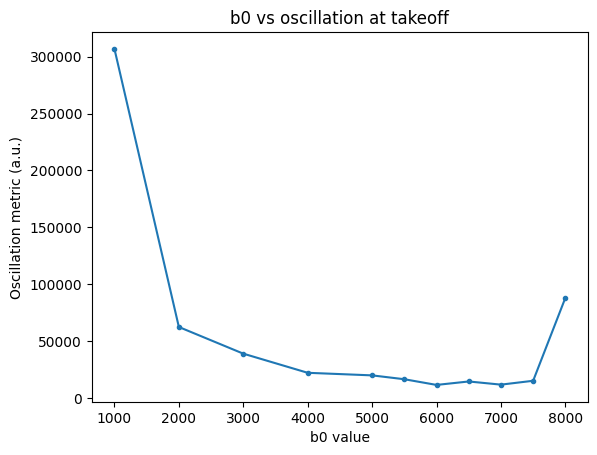

In [7]:
plt.plot(numbers, np.mean(deviation, axis = 1), marker = '.')
plt.title('b0 vs oscillation at takeoff')
plt.xlabel('b0 value')
plt.ylabel('Oscillation metric (a.u.)')

Text(0.5, 0, 'Time')

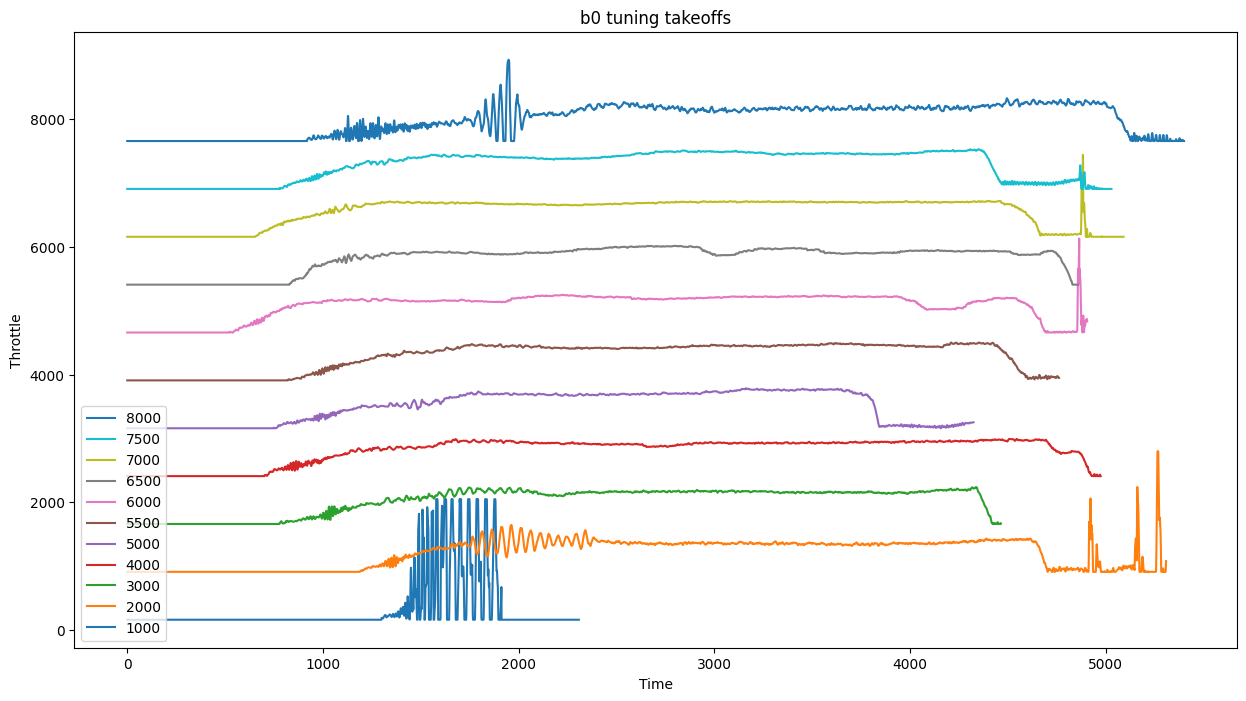

In [11]:
plt.figure(figsize = (15, 8))
for i in range (0, len(datasets)):
    plt.plot(datasets[i][:, 1]+i*750, label = numbers[i])
plt.legend(reverse = True, loc = 3)
plt.title('b0 tuning takeoffs')
plt.ylabel('Throttle')
plt.xlabel('Time')